In [ ]:
!pip install tensorflow

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape, Layer
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [2]:
# Load and preprocess MNIST data
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 28, 28, 1))

# Network parameters
input_shape = (28, 28, 1)
batch_size = 128
latent_dim = 2
intermediate_dim = 512
epochs = 5

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


NOTE: The following implementation for the VAE is referenced from the course material

In [8]:
class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [9]:
def build_models():
    # --- Define Encoder ---
    encoder_inputs = Input(shape=input_shape)
    x = Flatten()(encoder_inputs)
    x = Dense(intermediate_dim, activation='relu')(x)
    z_mean = Dense(latent_dim, name='z_mean')(x)
    z_log_var = Dense(latent_dim, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

    # --- Define Decoder ---
    decoder_inputs = Input(shape=(latent_dim,))
    x = Dense(intermediate_dim, activation='relu')(decoder_inputs)
    x = Dense(784, activation='sigmoid')(x)
    decoder_outputs = Reshape((28, 28, 1))(x)
    decoder = Model(decoder_inputs, decoder_outputs, name='decoder')

    return encoder, decoder


In [10]:
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name='total_loss')
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = tf.keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # Encoder output
            z_mean, z_log_var, z = self.encoder(data)
            # Reconstruction
            reconstruction = self.decoder(z)

            # Flatten input and reconstruction for binary crossentropy
            flat_data = tf.reshape(data, (-1, 784))
            flat_reconstruction = tf.reshape(reconstruction, (-1, 784))

            # Reconstruction loss (fixed axis handling)
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(
                    flat_data,
                    flat_reconstruction
                )
            ) * 784

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Compute gradients
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

In [12]:
def generate_digits(decoder, n=10):
    """Generate n new digits using the decoder"""
    z_sample = np.random.normal(size=(n, latent_dim))
    x_decoded = decoder.predict(z_sample)
    return x_decoded

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 22.8708 - loss: 375.0982 - reconstruction_loss: 352.2274
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 12.5148 - loss: 208.8573 - reconstruction_loss: 196.3425
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 8.3960 - loss: 195.8438 - reconstruction_loss: 187.4479
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.8408 - loss: 190.2014 - reconstruction_loss: 183.3605
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.1151 - loss: 186.6045 - reconstruction_loss: 180.4895
Visualizing latent space...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step


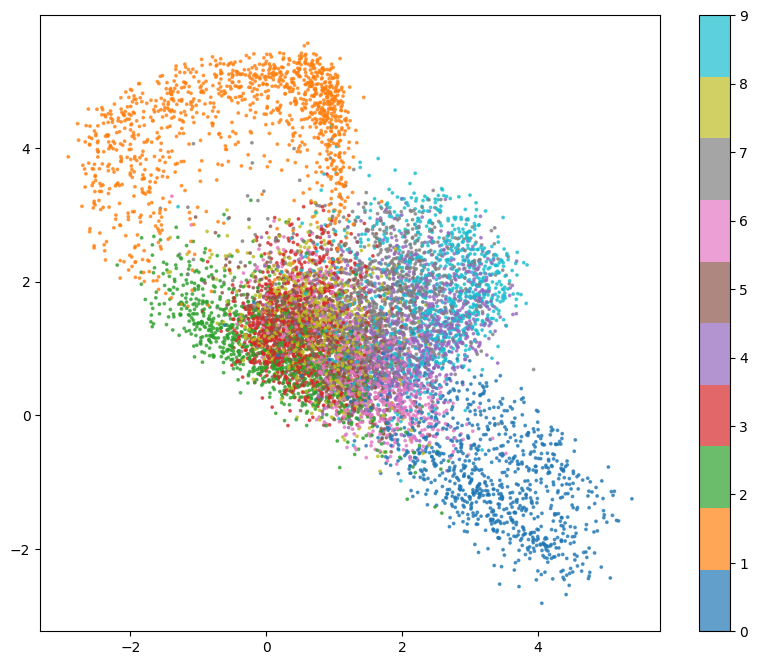

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


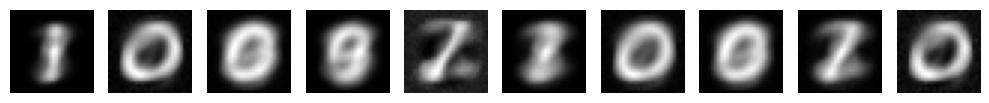

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 22.0121 - loss: 377.3045 - reconstruction_loss: 355.2924
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 12.8693 - loss: 208.5183 - reconstruction_loss: 195.6490
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 8.5607 - loss: 195.5032 - reconstruction_loss: 186.9425
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.8583 - loss: 190.3031 - reconstruction_loss: 183.4449
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.0565 - loss: 186.9928 - reconstruction_loss: 180.9363
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.6612 - loss: 183.9002 - reconstruction_loss: 178.2390
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.4022 - loss: 180.8295 - reconstruction_loss: 175.4273
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.1770 - loss: 177.5170 - reconstruction_loss: 172.3400
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms

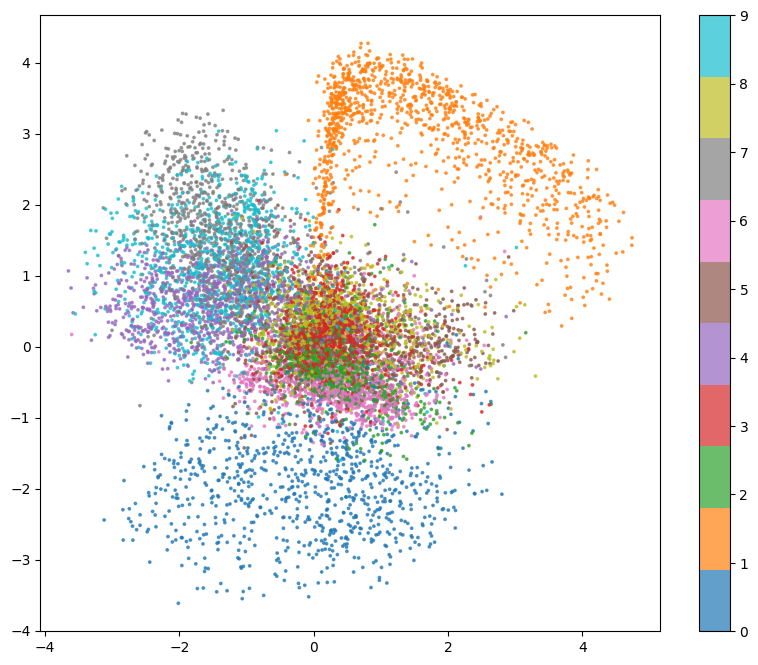

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


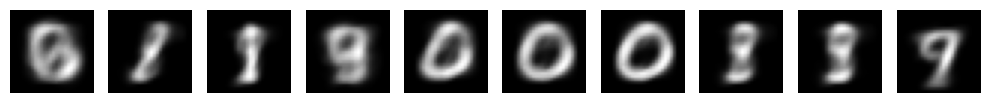

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 24.5912 - loss: 371.6075 - reconstruction_loss: 347.0163
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 12.9005 - loss: 208.7074 - reconstruction_loss: 195.8069
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 8.2907 - loss: 195.9370 - reconstruction_loss: 187.6462
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.5459 - loss: 191.2389 - reconstruction_loss: 184.6930
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.6636 - loss: 188.1531 - reconstruction_loss: 182.4896
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.3051 - loss: 185.6484 - reconstruction_loss: 180.3433
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.1213 - loss: 183.4011 - reconstruction_loss: 178.2798
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.0736 - loss: 180.1098 - reconstruction_loss: 175.0362
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms

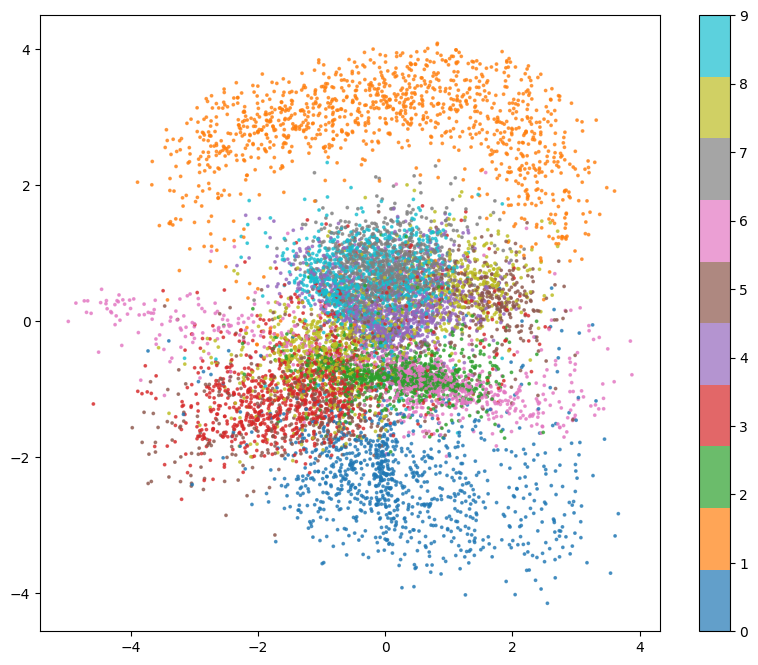

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


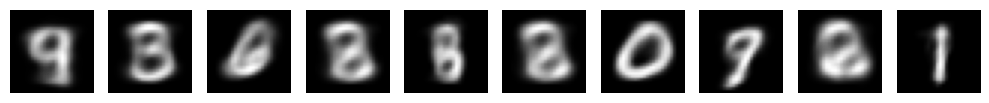

In [14]:
# Run experiments for epoch of 5, 15, 30
for e in [5, 15, 30]:
    encoder, decoder = build_models()

    vae = VAE(encoder, decoder)
    vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

    vae.fit(x_train,
        epochs=e,
        batch_size=batch_size,
        shuffle=True)

    # Visualize latent space
    print("Visualizing latent space...")
    (_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_test = x_test.astype('float32') / 255.
    x_test = x_test.reshape((len(x_test), 28, 28, 1))

    # Predict the coordinates
    z_mean, _, _ = encoder.predict(x_test)

    # Plot the latent space
    plt.figure(figsize=(10, 8))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, alpha=0.7, s=3, cmap='tab10')
    plt.colorbar()
    plt.show()

    new_digits = generate_digits(decoder, 10)  # Generates 10 new digits

    # Visualize the generated digits
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(new_digits[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# **Impact of different epochs on latent space**

Generally it is obserevd that the latent space gets more spread out and well defined for each digit, as epoch size increases.

*   5 Epochs: The clusters are tightly packed and heavily overlapping near the center $(0,0)$.
*   15 Epochs: The KL Divergence and Reconstruction Loss begin to balance. Clusters seperate from each other, forming distinct groups.
*   30 Epochs: The clusters are most spread out and sorted.



# **Impact of different epochs on generated digits**

Generally it is observed that the generated digits increases in clarity and distinctness, as epoch size increases.
*   5 Epochs: The digits appear blurry, with many digits like 0 and 8 looking very similar to each other.
*   15 Epochs: The shapes become recognizable. The general shapes of the numbers are clear, and the background noise disappears. There also starts to have some variation in handwritting style, comparing the 3 different 0 digits generated in different styles.
*   30 Epochs: The digits are the most sharp and high-contrast. The model has also learned the specific curves that distinguish similar digits like 0, 6, and 8.


Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 25.3714 - loss: 370.8684 - reconstruction_loss: 345.4971
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 11.8173 - loss: 206.4812 - reconstruction_loss: 194.6639
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 8.2019 - loss: 191.0616 - reconstruction_loss: 182.8597
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.8116 - loss: 185.8922 - reconstruction_loss: 179.0806
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.0054 - loss: 182.3862 - reconstruction_loss: 176.3808
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.5120 - loss: 179.9435 - reconstruction_loss: 174.4315
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.2789 - loss: 176.8965 - reconstruction_loss: 171.6177
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.1042 - loss: 174.2522 - reconstruction_loss: 169.1480
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms

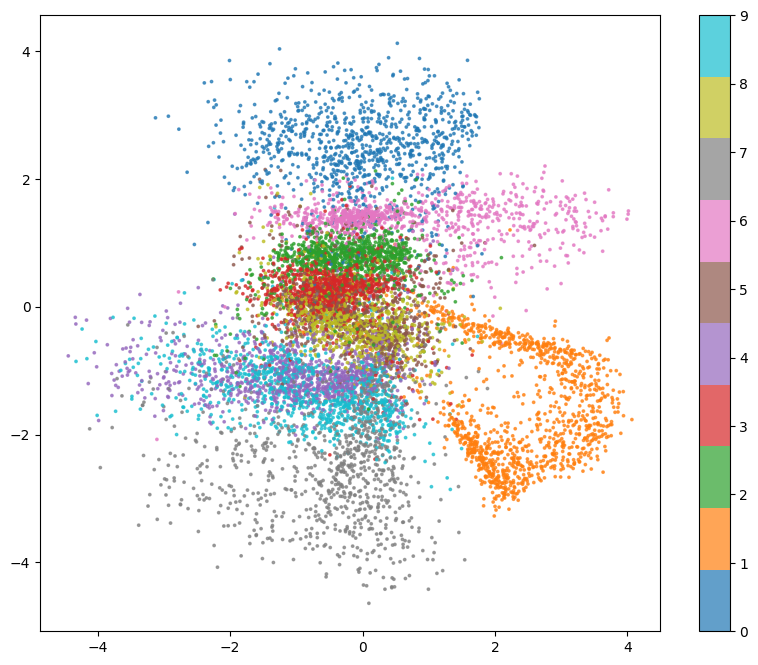

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


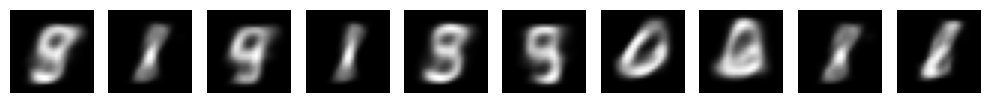

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 26.2464 - loss: 367.5515 - reconstruction_loss: 341.3051
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 12.3479 - loss: 205.8775 - reconstruction_loss: 193.5296
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 7.5789 - loss: 192.7621 - reconstruction_loss: 185.1832
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.0236 - loss: 188.2063 - reconstruction_loss: 182.1827
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.3474 - loss: 184.7303 - reconstruction_loss: 179.3829
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.0210 - loss: 181.3156 - reconstruction_loss: 176.2946
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 4.8206 - loss: 178.1912 - reconstruction_loss: 173.3706
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 4.7654 - loss: 175.3613 - reconstruction_loss: 170.5958
Epoch 9/100
469/469 ━━━━━━━━━━━━━━━━━━

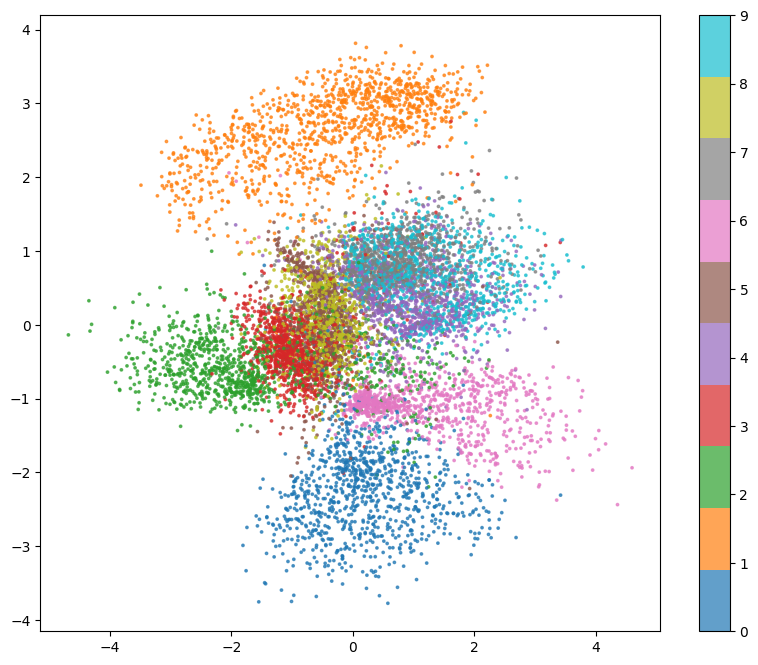

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


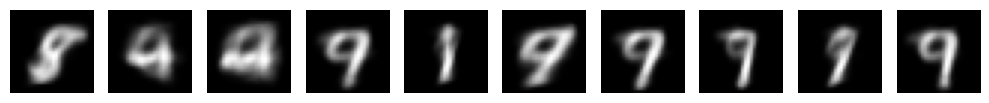

In [15]:
# Run optional experiments for epoch of 50 and 100
for e in [50, 100]:
    encoder, decoder = build_models()

    vae = VAE(encoder, decoder)
    vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

    vae.fit(x_train,
        epochs=e,
        batch_size=batch_size,
        shuffle=True)

    # Visualize latent space
    print("Visualizing latent space...")
    (_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_test = x_test.astype('float32') / 255.
    x_test = x_test.reshape((len(x_test), 28, 28, 1))

    # Predict the coordinates
    z_mean, _, _ = encoder.predict(x_test)

    # Plot the latent space
    plt.figure(figsize=(10, 8))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, alpha=0.7, s=3, cmap='tab10')
    plt.colorbar()
    plt.show()

    new_digits = generate_digits(decoder, 10)  # Generates 10 new digits

    # Visualize the generated digits
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(new_digits[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# **Impact of running higher epoch size (50, 100) on latent space**

It is observed that for a epoch size of 50, the latent space got more well defined, espeically around the center of the map, with the digits occupying a better sperated section each.

But for a epoch size of 100, it is observed that the latent space for the digits once again begun to merge around the center, leading to significant overlapping. This could be the result of KL Dominance or over regularization, as the model is trying to over minimize the KL loss, having already minimized the reconstruction loss as best it could.

# **Impact of runing higher epoch size (50, 100) on generated digits**

As a result of the visualized latent space in the experiment for the higher epoch sizes, we observe that for epoch size 50, the digits are marginally clearer, but with more variation in styles as compared to the experiment run with epoch size of 30.

But for the experiment with epoch size of 100, it is observed that the generated digits are less distinct, (e.g. observe that the generated digit 4 and 9 looks very similar to each other).